In [1]:
import jax
import jax.numpy as jnp
import numpyro
import matplotlib.pyplot as plt
import inspeqtor.experimental as sq
import numpyro.distributions as dist
import numpy as np
from numpyro.infer import (
    SVI,
    TraceMeanField_ELBO,
    autoguide,
    init_to_feasible,
)
from numpyro.util import enable_x64
from alive_progress import alive_it
import gen_data_v2 as ml
import pandas as pd
import scienceplots as scienceplots
import pathlib
import time
enable_x64(use_x64=True)

In [2]:
EXPERIMENT_ID = "0002-fixed"
data_path = pathlib.Path(f"./data/PSD/{EXPERIMENT_ID}")
# Ensure that path to dataset exists
assert data_path.exists()
# Read the noise setting first
config = sq.data.ExperimentConfiguration.from_file(data_path)
# Read the noise setting first
noise_config = config.additional_info
DETUNE = float(noise_config["DETUNE"])
NOISE_STR = float(noise_config["NOISE_STR"])
TROTTERIZATION = bool(noise_config["TROTTERIZATION"])
TROTTER_STEPS = int(noise_config["TROTTER_STEPS"])

# Setup model path
PGM_model_path = pathlib.Path(f'model/PSD/{EXPERIMENT_ID}/PGM')
PGM_model_path.mkdir(parents=True, exist_ok=True)

In [3]:
loaded_data = sq.predefined.load_data_from_path(
    data_path,
    hamiltonian_spec=sq.predefined.HamiltonianSpec(
        method=sq.predefined.WhiteboxStrategy.TROTTER
        if TROTTERIZATION
        else sq.predefined.WhiteboxStrategy.ODE,
        trotter_steps=TROTTER_STEPS,
    ),
)

key = jax.random.key(0)
key, random_split_key, train_key, prediction_key = jax.random.split(key, 4)
(
    train_pulse_parameters,
    train_unitaries,
    train_expectation_values,
    test_pulse_parameters,
    test_unitaries,
    test_expectation_values,
) = sq.utils.random_split(
    random_split_key,
    int(loaded_data.control_parameters.shape[0] * 0.1),  # Test size
    loaded_data.control_parameters,
    loaded_data.unitaries,
    loaded_data.expectation_values,
)

shots = loaded_data.experiment_data.experiment_config.shots

train_binaries = sq.utils.eigenvalue_to_binary(
    sq.utils.expectation_value_to_eigenvalue(train_expectation_values, shots)
)
train_binaries = jnp.swapaxes(jnp.swapaxes(train_binaries, 1, 2), 0, 1)

test_binaries = sq.utils.eigenvalue_to_binary(
    sq.utils.expectation_value_to_eigenvalue(test_expectation_values, shots)
)

test_binaries = jnp.swapaxes(jnp.swapaxes(test_binaries, 1, 2), 0, 1)

assert train_binaries.shape == (shots, train_pulse_parameters.shape[0], 18)
assert test_binaries.shape == (shots, test_pulse_parameters.shape[0], 18)

In [4]:
train_data = sq.optimize.DataBundled(
    control_params=ml.feature_map(train_pulse_parameters),
    unitaries=train_unitaries,
    observables=train_binaries,
    aux=train_expectation_values,
)

test_data = sq.optimize.DataBundled(
    control_params=ml.feature_map(test_pulse_parameters),
    unitaries=test_unitaries,
    observables=test_binaries,
    aux=test_expectation_values,
)

In [5]:
hidden_sizes = [[5], [5]]

base_model = sq.models.linen.WoModel(
    hidden_sizes_1=hidden_sizes[0], hidden_sizes_2=hidden_sizes[1]
)

use_bayesian_nn = True

graybox_model = sq.probabilistic.make_flax_probabilistic_graybox_model(
    name="graybox",
    base_model=base_model,
    adapter_fn=sq.probabilistic.observable_to_expvals,
    prior=dist.Normal(0, 1),
)
model = sq.probabilistic.make_probabilistic_model(
    predictive_model=graybox_model,
)

guide = sq.probabilistic.auto_diagonal_normal_guide(
    model, train_data.control_params, train_data.unitaries, train_data.observables
)

iterations = 10_000
optimizer = sq.optimize.get_default_optimizer(iterations)

svi = SVI(
    model=model,
    guide=guide,
    optim=numpyro.optim.optax_to_numpyro(optimizer),
    loss=TraceMeanField_ELBO(num_particles=1),
)


assert train_binaries.shape == (shots, train_pulse_parameters.shape[0], 18)

svi_state = svi.init(
    rng_key=jax.random.key(0),
    control_parameters=train_data.control_params,
    unitaries=train_data.unitaries,
    observables=train_data.observables,
)

update_fn = sq.probabilistic.make_update_fn(
    svi,
    control_parameters=train_data.control_params,
    unitaries=train_data.unitaries,
    observables=train_data.observables,
)

eval_fn = sq.probabilistic.make_evaluate_fn(
    svi,
    control_parameters=test_data.control_params,
    unitaries=test_data.unitaries,
    observables=test_data.observables,
)

start_time = time.time()
eval_losses = []
losses = []
for i in alive_it(range(iterations), force_tty=True):
    svi_state, loss = jax.jit(update_fn)(svi_state)
    eval_loss = jax.jit(eval_fn)(svi_state)
    losses.append(loss)
    eval_losses.append(eval_loss)
stop_time = time.time()

svi_result = sq.probabilistic.SVIRunResult(
    svi.get_params(svi_state), svi_state, jnp.stack(losses), jnp.stack(eval_losses)
)

print(stop_time - start_time, " second")

|████████████████████████████████████████| 10000/10000 [100%] in 4:48.0 (34.73/s
287.95969700813293  second


In [6]:
rescaled_eval_losses = svi_result.eval_losses / test_pulse_parameters.shape[0]
rescaled_train_losses = svi_result.losses / train_pulse_parameters.shape[0]

train_df = pd.DataFrame(
    {
        "loss": np.asarray(rescaled_train_losses),
        "type": "train",
        "iteration": np.arange(len(rescaled_train_losses)),
    }
)

eval_df = pd.DataFrame(
    {
        "loss": np.asarray(rescaled_eval_losses),
        "type": "eval",
        "iteration": np.arange(len(rescaled_eval_losses)),
    }
)

df = pd.concat([train_df, eval_df])
df.to_csv(PGM_model_path / "losses.csv")


result = sq.model.ModelData(
    params=svi_result.params,
    config={
        "shots": shots,
        "model": "WoBased",
        "model_config": {"hidden_sizes": hidden_sizes},
    },
)

result.to_file(PGM_model_path / "model.json")

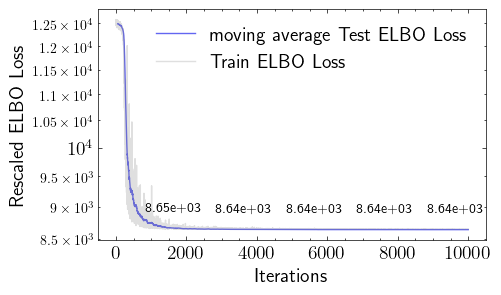

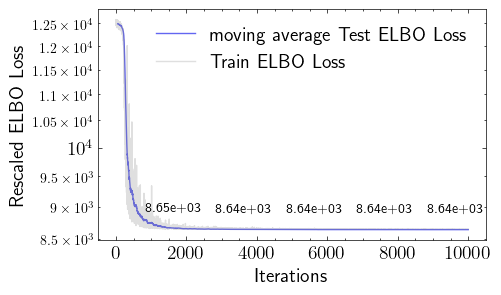

In [7]:
losses_df = pd.read_csv(PGM_model_path / 'losses.csv')
rescaled_train_losses = jnp.asarray(losses_df[losses_df['type'] == "train"]['loss'].to_numpy())
rescaled_eval_losses = jnp.asarray(losses_df[losses_df['type'] == "eval"]['loss'].to_numpy())

iterations = jnp.arange(len(rescaled_train_losses))
with plt.style.context(["science"]):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax = sq.visualization.plot_loss_with_moving_average(
        iterations,
        rescaled_eval_losses,
        ax=ax,
        color="#6366f1",
        label="moving average Test ELBO Loss",
    )
    ax = sq.visualization.plot_loss_with_moving_average(
        iterations,
        rescaled_train_losses,
        ax,
        window=1,
        annotate_at=[],
        color="gray",
        alpha=0.25,
        label="Train ELBO Loss",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Rescaled ELBO Loss")
    ax.legend()
    sq.visualization.set_fontsize(ax, 14)

fig.savefig("fig_pgm_training_loss.pdf")
fig

## Optimal control

In [8]:
from numpyro.infer import (
    Predictive
)

In [9]:
def make_optimal_control_problem(graybox, whitebox_fn):
    def optimal_control_problem(expected_outcomes: jnp.ndarray | None = None):
        control_params = numpyro.param("control_params", jnp.array([jnp.pi / 3]))

        assert isinstance(control_params, jnp.ndarray)
        assert control_params.shape == (1,)

        unitary_f = whitebox_fn(control_params)[-1, :, :]

        return graybox(ml.feature_map(control_params), unitary_f, expected_outcomes)

    return optimal_control_problem


def make_optimal_control_problem_v3(whitebox_fn, predictive_fn):
    def optimal_control_model(expected_outcomes: jnp.ndarray | None = None):
        control_params = numpyro.param("control_params", jnp.array([jnp.pi / 2]))
        unitary_f = whitebox_fn(control_params)[-1, :, :]

        assert isinstance(control_params, jnp.ndarray)
        assert control_params.shape == (1,)

        with numpyro.handlers.block():
            with numpyro.handlers.seed():
                key = numpyro.prng_key()
                expvals = predictive_fn(key, ml.feature_map(control_params), unitary_f)[
                    "expectation_values"
                ]

        return numpyro.sample(
            "obs",
            dist.BernoulliProbs(
                probs=sq.probabilistic.expectation_value_to_prob_minus(expvals)  # type: ignore
            ),
            obs=expected_outcomes,
        )

    return optimal_control_model


def make_prior_from_params(guide, params, num_samples=10000):
    posterior_distribution = Predictive(
        model=guide, params=params, num_samples=num_samples
    )(jax.random.key(0))
    return sq.probabilistic.construct_normal_prior_from_samples(posterior_distribution)

In [10]:
shots = loaded_data.experiment_data.experiment_config.shots

characterized_result = sq.probabilistic.SVIResult.from_file(
    PGM_model_path / "model.json"
)

base_model = sq.models.linen.WoModel(
    hidden_sizes_1=characterized_result.config["model_config"]["hidden_sizes"][0],
    hidden_sizes_2=characterized_result.config["model_config"]["hidden_sizes"][1],
)


graybox_model = sq.probabilistic.make_flax_probabilistic_graybox_model(
    name="graybox",
    base_model=base_model,
    adapter_fn=sq.probabilistic.observable_to_expvals,
    prior=dist.Normal(0, 1),
)
model = sq.probabilistic.make_probabilistic_model(
    predictive_model=graybox_model,
)

# initialize guide
guide = sq.probabilistic.auto_diagonal_normal_guide(
    model,
    ml.feature_map(loaded_data.control_parameters),
    loaded_data.unitaries,
    jnp.zeros(shape=(shots, loaded_data.control_parameters.shape[0], 18)),
)

In [11]:
expected_means = sq.utils.calculate_expectation_values(sq.constant.SX)

target_binaries = sq.utils.eigenvalue_to_binary(
    sq.utils.expectation_value_to_eigenvalue(expected_means, shots)
)
target_binaries = jnp.swapaxes(target_binaries, 0, 1)

predictive_fn = Predictive(
    model=sq.probabilistic.make_probabilistic_model(
        predictive_model=graybox_model,
        log_expectation_values=True,
    ),
    guide=guide,
    params=characterized_result.params,
    num_samples=1000,
)

optimal_control_model = make_optimal_control_problem_v3(
    whitebox_fn=loaded_data.whitebox, predictive_fn=predictive_fn
)


def opitmal_control_guide(expected_outcomes):
    pass


tx = sq.optimize.get_default_optimizer(8000)

svi = SVI(
    model=optimal_control_model,
    guide=opitmal_control_guide,
    optim=numpyro.optim.optax_to_numpyro(tx),
    loss=TraceMeanField_ELBO(),
)


svi_state = svi.init(
    rng_key=jax.random.key(0),
    expected_outcomes=target_binaries,
)

update_fn = sq.probabilistic.make_update_fn(
    svi,
    expected_outcomes=target_binaries,
)

start_time = time.time()
control_losses = []
for i in alive_it(range(1500), force_tty=True):
    svi_state, loss = jax.jit(update_fn)(svi_state)
    control_losses.append(loss)
stop_time = time.time()

res = sq.probabilistic.SVIRunResult(
    svi.get_params(svi_state), svi_state, jnp.stack(control_losses), jnp.stack(control_losses)
)

print(stop_time - start_time, " second")

|████████████████████████████████████████| 1500/1500 [100%] in 5:11.3 (4.82/s)  
311.30634212493896  second


In [12]:
optimal_control_params = res.params["control_params"]
sx_agf_fn = sq.physics.direct_AGF_estimation_fn(sq.constant.SX)
predicted_expvals = predictive_fn(
    jax.random.key(0),
    ml.feature_map(optimal_control_params),
    loaded_data.whitebox(optimal_control_params)[-1],
)["expectation_values"]
agf = sx_agf_fn(predicted_expvals.mean(axis=0))
assert isinstance(optimal_control_params, jnp.ndarray)
print("The optimized control paramters: ", optimal_control_params.item())
print("With AGF of ", agf.item())


The optimized control paramters:  1.4287427491651168
With AGF of  0.9999425990394265


In [13]:
# Below value should approximately the same as the one in the optimal control optimization.
jnp.sum(
    -1
    * numpyro.distributions.BernoulliProbs(
        probs=sq.utils.expectation_value_to_prob_minus(predicted_expvals)
    ).log_prob(target_binaries)
)

Array(8318.6936897, dtype=float64)

In [14]:
res.losses

Array([8379.42076392, 8379.5723028 , 8379.41835679, ..., 8318.78192053,
       8318.83601383, 8318.7341119 ], dtype=float64)

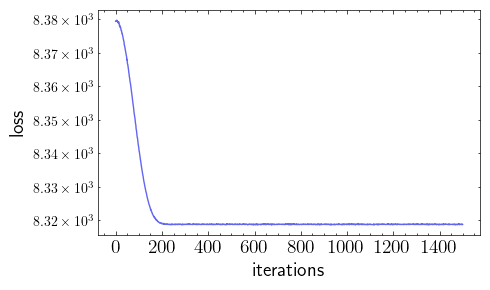

In [15]:
with plt.style.context("science"):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(res.losses, color="#6366f1")
    ax.set_yscale("log")
    ax.set_ylabel("loss")
    ax.set_xlabel("iterations")
    sq.visualization.set_fontsize(ax, 14)

fig.tight_layout()
fig.savefig("fig_pgm_control_loss.pdf")
fig

In [16]:
import numpy as np

df = pd.DataFrame({"loss": np.array(res.losses)})
df.to_csv(PGM_model_path / "control_loss.csv")